In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.stem import PorterStemmer
from collections import Counter
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE

In [29]:
nltk.download('stopwords',download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
with open('../static/model/corpora/stopwords/english','r') as file:
    sw = file.read().splitlines()

In [31]:
print(sw[:50])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn']


In [32]:
ps = PorterStemmer()

##  Data Loading and Cleaning 

In [33]:
# Load dataset
data = pd.read_csv('../artifacts/tripadvisor_extended_1000.csv')

In [34]:
print("Train data shape:", data.shape)
print("\nTrain data sample:")
data.tail(10)

Train data shape: (7552, 3)

Train data sample:


,id,tweet,label
7542,7543,"Enjoyed my time here. The pool was clean, and ...",2
7543,7544,"Enjoyed my time here. The pool was clean, and ...",2
7544,7545,"Bad experience! The location was good, but eve...",0
7545,7546,Best experience ever! The hotel ambiance was p...,2
7546,7547,"Bad experience! The location was good, but eve...",0
7547,7548,The noise was unbearable. Couldn’t sleep all n...,0
7548,7549,Totally regret booking this place. Stay away! ...,0
7549,7550,"A reasonable place for a short stay, but nothi...",1
7550,7551,It was fine for a business trip. Nothing too f...,1
7551,7552,"Not worth the money. The rooms smelled bad, an...",0


In [35]:
print("Train data shape: ",data.shape)
print("\nDuplicates: ",data.duplicated().sum())
print("\nNull values:\n",data.isnull().sum())

Train data shape:  (7552, 3)

Duplicates:  0

Null values:
 id       0
tweet    0
label    0
dtype: int64


## Preprocessing Function

In [36]:
# ----------------- Preprocessing Function -----------------
def preprocess_text(text):
    # 1. Convert text to lowercase (splitting and joining to mimic your original method)
    text = " ".join(word.lower() for word in text.split())
    
    # 2. Remove links: apply regex to each word in the sentence
    text = " ".join(re.sub(r'^https?:\/\/.*[\r\n]*', '', word, flags=re.MULTILINE) for word in text.split())
    
    # 3. Remove punctuations: iterate through all punctuation symbols
    for p in string.punctuation:
        text = text.replace(p, '')
    
    # 4. Remove numbers using regex
    text = re.sub(r'\d+', '', text)
    
    # 5. Remove stopwords using the loaded list (SW)
    text = " ".join(word for word in text.split() if word not in sw)
    
    # 6. Apply stemming (Porter Stemmer)
    text = " ".join(ps.stem(word) for word in text.split())
    
    return text

## Apply preprocessing to the 'tweet' column

In [37]:
data["tweet"] = data["tweet"].apply(preprocess_text)
print("Sample preprocessed tweets:\n", data["tweet"].head())

Sample preprocessed tweets:
 0    nice averag stay recent midoctob got good deal...
1    westin rio mar worth trip friend return day we...
2    okay great stay apolo tryp night pretti standa...
3    good great stay friend neri earli thought grea...
4    poor custom servic poor custom servic respond ...
Name: tweet, dtype: object


## Vocabulary Building

In [38]:
# Build vocabulary using Counter
vocab = Counter()
for sentence in data['tweet']:
    vocab.update(sentence.split())
print("Most common tokens:\n", vocab.most_common(50))
print("Dataset Shape: ", data.shape)
print("Vocabulary Size: ", len(vocab))

Most common tokens:
 [('room', 17502), ('hotel', 16450), ('stay', 9467), ('nt', 7363), ('good', 5676), ('great', 5507), ('staff', 5147), ('night', 5086), ('day', 4647), ('time', 4630), ('nice', 4435), ('servic', 4185), ('locat', 4169), ('like', 3668), ('beach', 3667), ('place', 3641), ('resort', 3449), ('clean', 3426), ('food', 3378), ('restaur', 3197), ('bed', 2902), ('walk', 2817), ('pool', 2773), ('breakfast', 2705), ('peopl', 2515), ('realli', 2467), ('got', 2407), ('small', 2362), ('look', 2356), ('book', 2320), ('want', 2281), ('area', 2272), ('help', 2245), ('desk', 2172), ('littl', 2064), ('need', 2035), ('check', 2034), ('price', 2011), ('bathroom', 2001), ('make', 1978), ('ask', 1921), ('water', 1912), ('use', 1878), ('bar', 1863), ('friendli', 1840), ('thing', 1789), ('arriv', 1780), ('review', 1779), ('tri', 1775), ('view', 1765)]
Dataset Shape:  (7552, 3)
Vocabulary Size:  30056


In [39]:
# Filter tokens with frequency > 2
tokens = [key for key in vocab if vocab[key] > 2]
print('\nFiltered Token Size: ', len(tokens))


Filtered Token Size:  8518


In [40]:
# Save the filtered vocabulary to a file
def save_vocabulary(lines, filename):
    vocab_data = '\n'.join(lines)
    with open(filename, 'w', encoding="utf-8") as file:
        file.write(vocab_data)

save_vocabulary(tokens, '../static/model/vocabulary.txt')

##  Data Splitting

In [41]:
# Divide dataset into features and labels
x = data['tweet']
y = data['label']

In [42]:
# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (6041,)
x_test shape: (1511,)


### Define vectorization function: create a binary vector (1 if token is present)

In [43]:
# Define vectorization function: create a binary vector (1 if token is present)
def vectorizer(ds, vocabulary):
    vectorized = []
    for sentence in ds:
        sentence_vector = np.zeros(len(vocabulary))
        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_vector[i] = 1
        vectorized.append(sentence_vector)
    return np.asarray(vectorized, dtype=np.float32)

In [44]:
vectorized_x_train = vectorizer(x_train, tokens)
print("Finish vectorized_x_train")
vectorized_x_test = vectorizer(x_test, tokens)
print("Finish vectorized_x_test")

Finish vectorized_x_train
Finish vectorized_x_test


In [45]:
y_train.value_counts()

label
2    2032
1    2007
0    2002
Name: count, dtype: int64

## Visualize Class Distribution

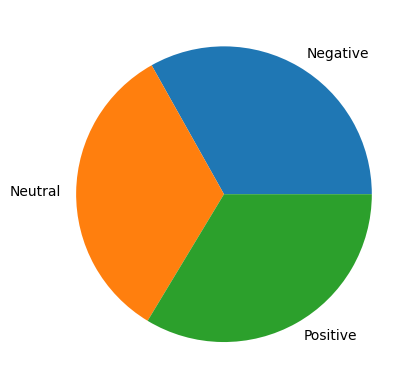

In [46]:

plt.pie(np.array([y_train.value_counts()[0], 
                  y_train.value_counts()[1], 
                  y_train.value_counts()[2]]),
        labels=['Negative', 'Neutral', 'Positive'])
plt.show()

## Handling Imbalanced Dataset 

In [47]:
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)
print("Value counts after SMOTE:\n", y_train_smote.value_counts())

(6096, 8518) (6096,)
Value counts after SMOTE:
 label
0    2032
1    2032
2    2032
Name: count, dtype: int64


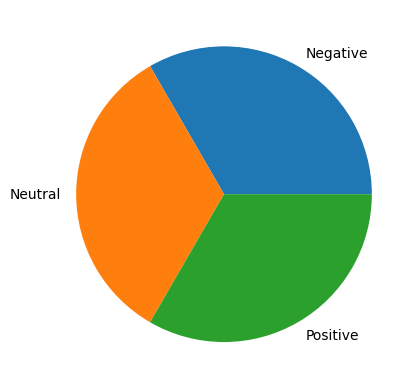

In [48]:
plt.pie(np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1], y_train_smote.value_counts()[2]]),
        labels=['Negative', 'Neutral', 'Positive'])
plt.show()

## Model Training and Evaluation

In [49]:
def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Training Scores: \n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')
    
def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Testing Scores: \n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')


## --- Logistic Regression ---

In [58]:
# Logistic Regression (Original)
lr = LogisticRegression(max_iter=1000)
lr.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = lr.predict(vectorized_x_train_smote)
y_test_pred = lr.predict(vectorized_x_test)
print("Logistic Regression (Original):")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)

Logistic Regression (Original):
Training Scores: 
	Accuracy = 0.999
	Precision = 0.999
	Recall = 0.999
	F1-Score = 0.999
Testing Scores: 
	Accuracy = 0.76
	Precision = 0.76
	Recall = 0.76
	F1-Score = 0.759


## --- Naive Bayes (MultinomialNB) ---

In [51]:
# MultinomialNB (Original)
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = mnb.predict(vectorized_x_train_smote)
y_test_pred = mnb.predict(vectorized_x_test)
print("\nMultinomialNB (Original):")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)


MultinomialNB (Original):
Training Scores: 
	Accuracy = 0.879
	Precision = 0.879
	Recall = 0.879
	F1-Score = 0.879
Testing Scores: 
	Accuracy = 0.782
	Precision = 0.786
	Recall = 0.782
	F1-Score = 0.782


## --- Decision Tree ---

In [52]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = dt.predict(vectorized_x_train_smote)
y_test_pred = dt.predict(vectorized_x_test)
print("\nDecision Tree:")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)


Decision Tree:
Training Scores: 
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores: 
	Accuracy = 0.613
	Precision = 0.612
	Recall = 0.613
	F1-Score = 0.612


## --- Random Forest ---

In [53]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = rf.predict(vectorized_x_train_smote)
y_test_pred = rf.predict(vectorized_x_test)
print("\nRandom Forest:")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)


Random Forest:
Training Scores: 
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores: 
	Accuracy = 0.733
	Precision = 0.734
	Recall = 0.733
	F1-Score = 0.733


# --- Support Vector Classifier (SVC) ---

In [54]:
# # SVC
# svc = SVC()
# svc.fit(vectorized_x_train_smote, y_train_smote)
# y_train_pred = svc.predict(vectorized_x_train_smote)
# y_test_pred = svc.predict(vectorized_x_test)
# print("\nSVC:")
# training_scores(y_train_smote, y_train_pred)
# validation_scores(y_test, y_test_pred)

In [55]:
# ----------------- Hyperparameter Tuning -----------------
# Hyperparameter tuning for MultinomialNB and Logistic Regression using GridSearchCV.
# MultinomialNB tuning:
nb_param_grid = {'alpha': [0.5, 1.0, 2.0, 5.0, 10.0]}
grid_mnb = GridSearchCV(MultinomialNB(), nb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_mnb.fit(vectorized_x_train_smote, y_train_smote)
print("\nBest parameters for MultinomialNB:", grid_mnb.best_params_)
print("Best cross-validation score (MultinomialNB):", grid_mnb.best_score_)
best_mnb = grid_mnb.best_estimator_
y_train_pred_nb = best_mnb.predict(vectorized_x_train_smote)
y_test_pred_nb = best_mnb.predict(vectorized_x_test)
print("\nMultinomialNB (Tuned):")
training_scores(y_train_smote, y_train_pred_nb)
validation_scores(y_test, y_test_pred_nb)


Best parameters for MultinomialNB: {'alpha': 0.5}
Best cross-validation score (MultinomialNB): 0.7839562124288924

MultinomialNB (Tuned):
Training Scores: 
	Accuracy = 0.888
	Precision = 0.888
	Recall = 0.888
	F1-Score = 0.888
Testing Scores: 
	Accuracy = 0.781
	Precision = 0.785
	Recall = 0.781
	F1-Score = 0.782


In [56]:
# Logistic Regression tuning:
lr_param_grid = {'C': [0.01, 0.1, 1, 10, 100, 1000]}
lr_tuned = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
grid_lr = GridSearchCV(lr_tuned, lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(vectorized_x_train_smote, y_train_smote)
print("\nBest Logistic Regression Parameters:", grid_lr.best_params_)
print("Best cross-validation score (Logistic Regression):", grid_lr.best_score_)
best_lr = grid_lr.best_estimator_
y_train_pred_lr = best_lr.predict(vectorized_x_train_smote)
y_test_pred_lr = best_lr.predict(vectorized_x_test)
print("\nLogistic Regression (Tuned):")
training_scores(y_train_smote, y_train_pred_lr)
validation_scores(y_test, y_test_pred_lr)


D:\1.ICBT\FINAL_RESEARCH_PROJECT\Back_End\travel_app_ml_back_end\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Best Logistic Regression Parameters: {'C': 0.01}
Best cross-validation score (Logistic Regression): 0.7691935071746527

Logistic Regression (Tuned):
Training Scores: 
	Accuracy = 0.853
	Precision = 0.853
	Recall = 0.853
	F1-Score = 0.853
Testing Scores: 
	Accuracy = 0.777
	Precision = 0.777
	Recall = 0.777
	F1-Score = 0.777


# download Best Model

In [30]:
# import pickle
# with open('../static/model/model_final.pickle','wb') as file:
#     pickle.dump(mnb,file)